In [1]:
import yfinance as yf
import pandas as pd

ticker = "GLD"
gold_data = yf.download(
    ticker,
    start="2000-01-01",
    end=None,
    progress=False,
    auto_adjust=False,
    actions=True,
)
gold_data

Price,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD,GLD
Date,,,,,,,,,
2004-11-18,44.380001,0.0,44.380001,0.0,44.490002,44.070000,44.430000,0.0,5992000
2004-11-19,44.779999,0.0,44.779999,0.0,44.919998,44.470001,44.490002,0.0,11655300
2004-11-22,44.950001,0.0,44.950001,0.0,44.970001,44.740002,44.750000,0.0,11996000
2004-11-23,44.750000,0.0,44.750000,0.0,44.919998,44.720001,44.880001,0.0,3169200
2004-11-24,45.049999,0.0,45.049999,0.0,45.049999,44.790001,44.930000,0.0,6105100
...,...,...,...,...,...,...,...,...,...
2025-04-23,303.649994,0.0,303.649994,0.0,304.739990,300.589996,304.179993,0.0,25421500
2025-04-24,308.070007,0.0,308.070007,0.0,308.500000,304.709991,306.980011,0.0,10845000


In [ ]:
cluster_data = pd.read_csv("../data/staged/cluster_embedding_output.csv")
cluster_data.head()

,Dates,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
0,2000-02-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-02-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2000-03-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2000-04-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2000-05-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [3]:
# finbert_score["Date"] = pd.to_datetime(finbert_score["Date"])
cluster_data["Date"] = pd.to_datetime(cluster_data["Dates"])

In [4]:
gold_data.reset_index(inplace=True)
gold_data.columns = [col[0] for col in gold_data.columns]

gold_data["Date"] = pd.to_datetime(gold_data["Date"])

In [5]:
merged_df = pd.merge(cluster_data, gold_data, on="Date", how="inner")
# merged_df = pd.merge(
#     merged_df, cluster_data, left_on="Date", right_on="Date", how="inner"
# )

In [6]:
merged_df.columns

Index(['Dates', 'topic_china_fed_and_gold_focus',
       'topic_comex_gold_closing_prices', 'topic_early_gold_trading_activity',
       'topic_economic_data_and_gold_performance',
       'topic_global_cues_and_gold_stability',
       'topic_global_investment_and_rate_impact',
       'topic_gold_climbs_in_trading', 'topic_gold_holds_as_data_releases',
       'topic_gold_market_turning_points', 'topic_gold_near_monthly_lows',
       'topic_gold_price_support_levels', 'topic_gold_prices_and_metal_shares',
       'topic_gold_settlement_price_correction',
       'topic_gold_spot_price_outlook',
       'topic_gold_trading_momentum_continues',
       'topic_market_rates_and_gold_demand',
       'topic_rate_hikes/cuts_price_impact', 'topic_time_sensitive_prediction',
       'topic_noise', 'Date', 'Adj Close', 'Capital Gains', 'Close',
       'Dividends', 'High', 'Low', 'Open', 'Stock Splits', 'Volume'],
      dtype='object')

In [7]:
df = merged_df[
    [
        "Date",
        "Open",
        "topic_china_fed_and_gold_focus",
        "topic_comex_gold_closing_prices",
        "topic_early_gold_trading_activity",
        "topic_economic_data_and_gold_performance",
        "topic_global_cues_and_gold_stability",
        "topic_global_investment_and_rate_impact",
        "topic_gold_climbs_in_trading",
        "topic_gold_holds_as_data_releases",
        "topic_gold_market_turning_points",
        "topic_gold_near_monthly_lows",
        "topic_gold_price_support_levels",
        "topic_gold_prices_and_metal_shares",
        "topic_gold_settlement_price_correction",
        "topic_gold_spot_price_outlook",
        "topic_gold_trading_momentum_continues",
        "topic_market_rates_and_gold_demand",
        "topic_rate_hikes/cuts_price_impact",
        "topic_time_sensitive_prediction",
        "topic_noise",
    ]
]

df

,Date,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,...,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
0,2004-11-18,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,2004-11-19,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2004-11-22,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2004-11-23,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2004-11-24,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2019-01-25,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2915,2019-01-28,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2916,2019-01-30,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2917,2019-01-31,125.180000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [8]:
# make date the index
df.index = df.pop("Date")
df

,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
Date,,,,,,,,,,,,,,,,,,,,
2004-11-18,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2004-11-19,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-22,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2004-11-23,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-24,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-25,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-28,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-30,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


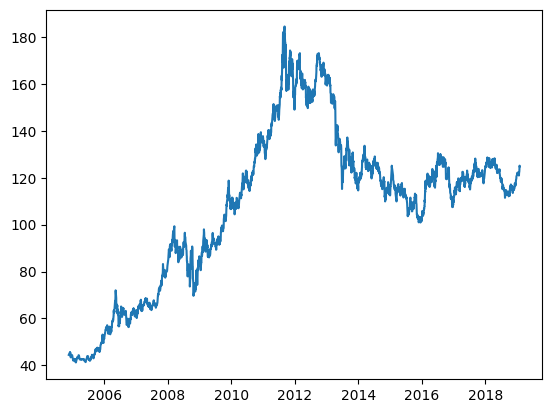

In [9]:
import matplotlib.pyplot as plt

plt.plot(df.index, df["Open"])

In [10]:
import numpy as np


def df_to_windowed_df(dataframe, n=3):
    dates = []
    X, Y = [], []

    for i in range(n, len(dataframe)):
        window = dataframe.iloc[i - n : i + 1]  # n previous + 1 target row

        if len(window) != n + 1:
            continue  # skip if not enough data

        values = window[
            [
                "Open",
                "topic_china_fed_and_gold_focus",
                "topic_comex_gold_closing_prices",
                "topic_early_gold_trading_activity",
                "topic_economic_data_and_gold_performance",
                "topic_global_cues_and_gold_stability",
                "topic_global_investment_and_rate_impact",
                "topic_gold_climbs_in_trading",
                "topic_gold_holds_as_data_releases",
                "topic_gold_market_turning_points",
                "topic_gold_near_monthly_lows",
                "topic_gold_price_support_levels",
                "topic_gold_prices_and_metal_shares",
                "topic_gold_settlement_price_correction",
                "topic_gold_spot_price_outlook",
                "topic_gold_trading_momentum_continues",
                "topic_market_rates_and_gold_demand",
                "topic_rate_hikes/cuts_price_impact",
                "topic_time_sensitive_prediction",
                "topic_noise",
            ]
        ].to_numpy()
        x, y = values[:-1], values[-1][0]

        dates.append(dataframe.index[i])  # the date corresponding to the target
        X.append(x)
        Y.append(y)

    ret_df = pd.DataFrame({"Target Date": dates})

    X = np.array(X)
    for i in range(n):
        ret_df[f"Target-{n - i}"] = list(
            X[:, i]
        )  # each element is a pair: [Close, sentiment]

    ret_df["Target"] = Y

    return ret_df

In [11]:
windowed_df = df_to_windowed_df(df, n=3)
windowed_df

,Target Date,Target-3,Target-2,Target-1,Target
0,2004-11-23,"[44.43000030517578, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[44.4900016784668, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[44.75, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...",44.880001
1,2004-11-24,"[44.4900016784668, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[44.75, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...","[44.880001068115234, 0.0, 1.0, 0.0, 0.0, 0.0, ...",44.930000
2,2004-11-29,"[44.75, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0...","[44.880001068115234, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[44.93000030517578, 0.0, 1.0, 0.0, 0.0, 0.0, 0...",45.099998
3,2004-11-30,"[44.880001068115234, 0.0, 1.0, 0.0, 0.0, 0.0, ...","[44.93000030517578, 0.0, 1.0, 0.0, 0.0, 0.0, 0...","[45.099998474121094, 0.0, 0.0, 0.0, 2.0, 0.0, ...",45.369999
4,2004-12-01,"[44.93000030517578, 0.0, 1.0, 0.0, 0.0, 0.0, 0...","[45.099998474121094, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[45.369998931884766, 0.0, 0.0, 0.0, 1.0, 0.0, ...",45.279999
...,...,...,...,...,...
2911,2019-01-25,"[122.27999877929688, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[120.95999908447266, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[121.16000366210938, 0.0, 0.0, 0.0, 0.0, 0.0, ...",122.019997
2912,2019-01-28,"[120.95999908447266, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[121.16000366210938, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[122.0199966430664, 0.0, 0.0, 0.0, 0.0, 0.0, 0...",122.750000
2913,2019-01-30,"[121.16000366210938, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[122.0199966430664, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[122.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",123.910004
2914,2019-01-31,"[122.0199966430664, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[122.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[123.91000366210938, 0.0, 0.0, 0.0, 0.0, 0.0, ...",125.180000


In [12]:
df

,Open,topic_china_fed_and_gold_focus,topic_comex_gold_closing_prices,topic_early_gold_trading_activity,topic_economic_data_and_gold_performance,topic_global_cues_and_gold_stability,topic_global_investment_and_rate_impact,topic_gold_climbs_in_trading,topic_gold_holds_as_data_releases,topic_gold_market_turning_points,topic_gold_near_monthly_lows,topic_gold_price_support_levels,topic_gold_prices_and_metal_shares,topic_gold_settlement_price_correction,topic_gold_spot_price_outlook,topic_gold_trading_momentum_continues,topic_market_rates_and_gold_demand,topic_rate_hikes/cuts_price_impact,topic_time_sensitive_prediction,topic_noise
Date,,,,,,,,,,,,,,,,,,,,
2004-11-18,44.430000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2004-11-19,44.490002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-22,44.750000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2004-11-23,44.880001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2004-11-24,44.930000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-25,122.019997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-28,122.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-01-30,123.910004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
def windowed_df_to_date_X_y(windowed_dataframe):
    dates = windowed_dataframe["Target Date"].to_numpy()

    feature_cols = windowed_dataframe.columns[1:-1]

    X = []
    for _, row in windowed_dataframe[feature_cols].iterrows():
        # Each val is a [Close, Sentiment] pair
        values = [val for val in row]  # Keep as 2D structure
        X.append(values)

    X = np.array(X)  # Shape will be (num_rows, n, 2)
    Y = windowed_dataframe["Target"].to_numpy()

    return dates, X.astype(np.float32), Y.astype(np.float32)


dates, X, y = windowed_df_to_date_X_y(windowed_df)

# check all the shapes
dates.shape, X.shape, y.shape

((2916,), (2916, 3, 20), (2916,))

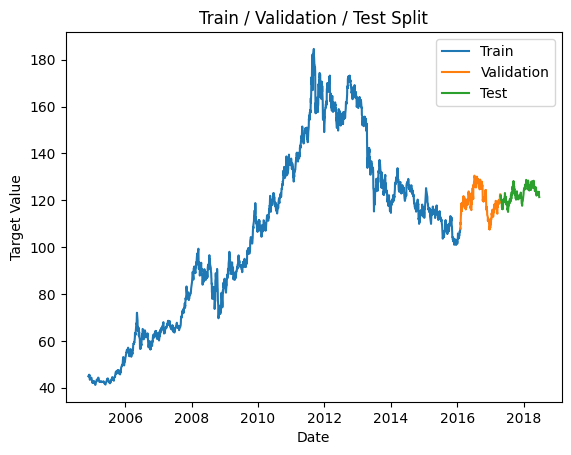

In [14]:
# training part
q_75 = int(len(dates) * 0.75)

# validation part
q_85 = int(len(dates) * 0.85)

# testing part
q_95 = int(len(dates) * 0.95)

dates_train, X_train, y_train = dates[:q_75], X[:q_75], y[:q_75]
dates_val, X_val, y_val = dates[q_75:q_85], X[q_75:q_85], y[q_75:q_85]
dates_test, X_test, y_test = dates[q_85:q_95], X[q_85:q_95], y[q_85:q_95]
dates_hold, X_hold, y_hold = dates[q_95:], X[q_95:], y[q_95:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(["Train", "Validation", "Test"])
plt.xlabel("Date")
plt.ylabel("Target Value")
plt.title("Train / Validation / Test Split")
plt.show()

In [15]:
X_train

array([[[ 44.43,   0.  ,   0.  , ...,   0.  ,   0.  ,   2.  ],
        [ 44.49,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [ 44.75,   0.  ,   0.  , ...,   0.  ,   0.  ,   1.  ]],

       [[ 44.49,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [ 44.75,   0.  ,   0.  , ...,   0.  ,   0.  ,   1.  ],
        [ 44.88,   0.  ,   1.  , ...,   0.  ,   0.  ,   0.  ]],

       [[ 44.75,   0.  ,   0.  , ...,   0.  ,   0.  ,   1.  ],
        [ 44.88,   0.  ,   1.  , ...,   0.  ,   0.  ,   0.  ],
        [ 44.93,   0.  ,   1.  , ...,   0.  ,   0.  ,   1.  ]],

       ...,

       [[105.76,   1.  ,   0.  , ...,   0.  ,   0.  ,   2.  ],
        [106.32,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [106.86,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]],

       [[106.32,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [106.86,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [106.55,   1.  ,   0.  , ...,   0.  ,   0.  ,   1.  ]],

       [[106.86,   0.  ,   0.  ,

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential(
    [
        layers.Input((3, 20)),  # window size = 3, feature = 2
        layers.LSTM(64),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)  # since the output we want is just 1

model.compile(
    loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mean_absolute_error"]
)

model.fit(
    X_train, y_train, validation_data=(X_val, y_val), epochs=100
)  # 100 runs through the dataset

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13130.5781 - mean_absolute_error: 108.3282 - val_loss: 10004.6680 - val_mean_absolute_error: 99.8669
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6048.7104 - mean_absolute_error: 66.4039 - val_loss: 103.0559 - val_mean_absolute_error: 8.8846
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 832.6546 - mean_absolute_error: 22.3407 - val_loss: 24.3184 - val_mean_absolute_error: 4.0619
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.3883 - mean_absolute_error: 2.7194 - val_loss: 9.4521 - val_mean_absolute_error: 2.5083
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.8201 - mean_absolute_error: 1.5090 - val_loss: 7.5085 - val_mean_absolute_error: 2.2656
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.8648 - mean_absolute_error: 1.5152 - val_loss: 6.4029 - val_mean_absolute_error: 2.1406
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7864 - mean_absolute_er

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


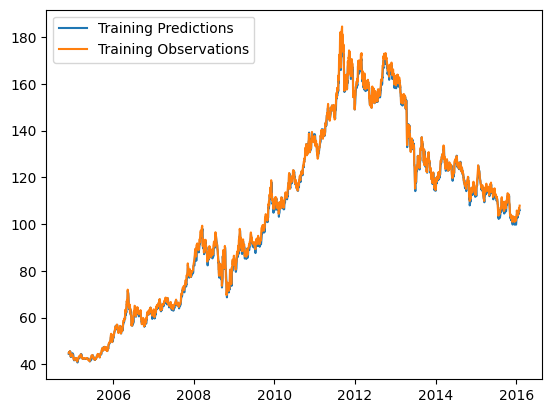

In [17]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(["Training Predictions", "Training Observations"])

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
)
import numpy as np


mae = mean_absolute_error(y_train, train_predictions)
mse = mean_squared_error(y_train, train_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_predictions)
mape = mean_absolute_percentage_error(y_train, train_predictions)
explained_var = explained_variance_score(y_train, train_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1560
MSE: 2.4823
RMSE: 1.5755
R² Score: 0.9982
MAPE: 0.0109
Explained Variance: 0.9985


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


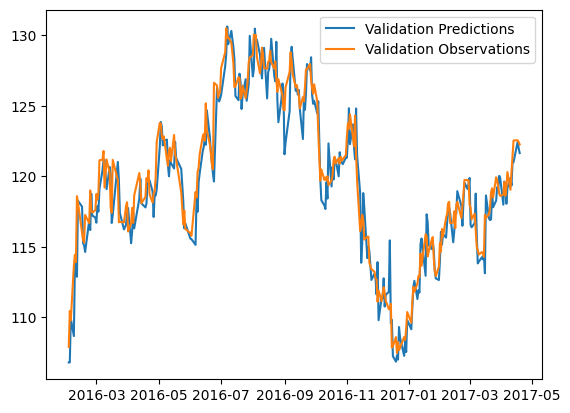

In [19]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(["Validation Predictions", "Validation Observations"])

In [20]:
mae = mean_absolute_error(y_val, val_predictions)
mse = mean_squared_error(y_val, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, val_predictions)
mape = mean_absolute_percentage_error(y_val, val_predictions)
explained_var = explained_variance_score(y_val, val_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.1630
MSE: 2.3763
RMSE: 1.5415
R² Score: 0.9197
MAPE: 0.0097
Explained Variance: 0.9244


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


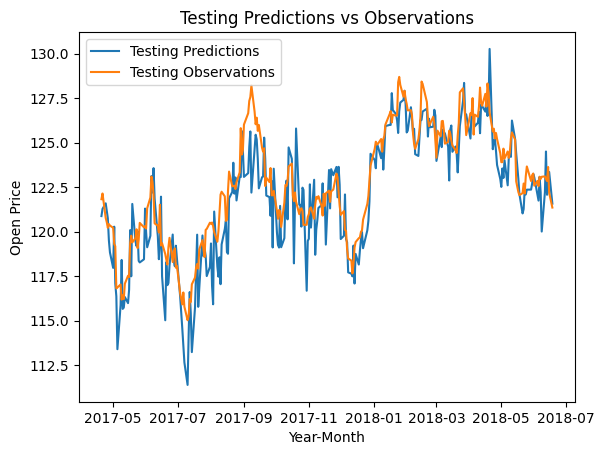

In [21]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(["Testing Predictions", "Testing Observations"])
plt.xlabel("Year-Month")  # x-axis label
plt.ylabel("Open Price")  # y-axis label
plt.title("Testing Predictions vs Observations")
plt.show()

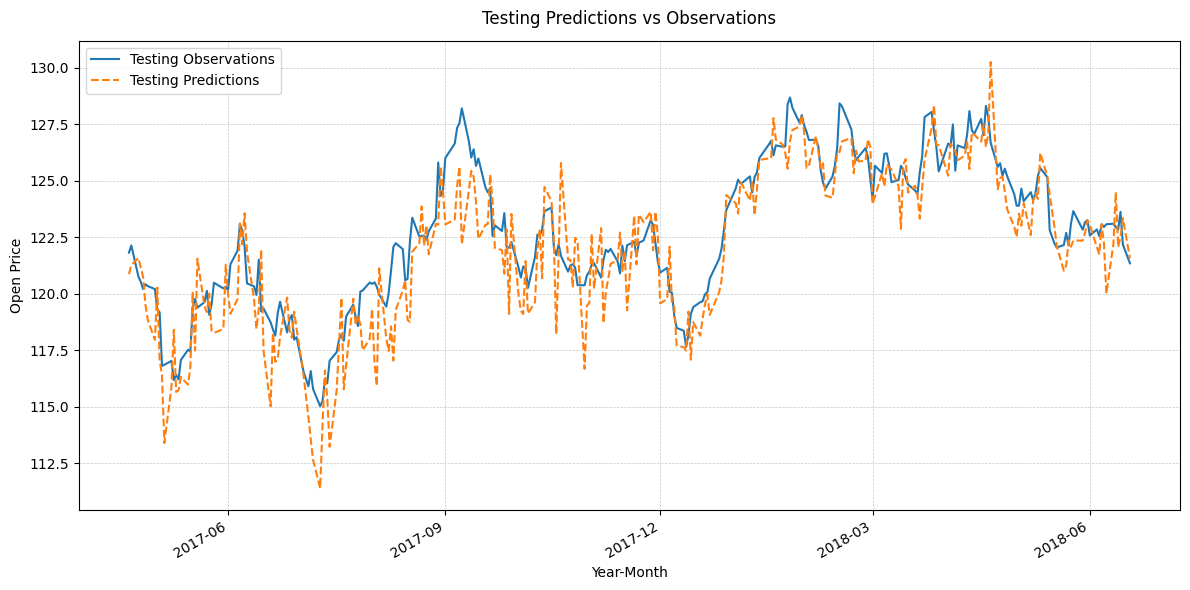

In [22]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# your data
# dates_test, y_test, test_predictions

fig, ax = plt.subplots(figsize=(12, 6))

# force a white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# plot the actuals
ax.plot(
    dates_test, y_test, label="Testing Observations", color="tab:blue", linewidth=1.5
)

# plot the preds
ax.plot(
    dates_test,
    test_predictions,
    label="Testing Predictions",
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
)

# labels & title
ax.set_xlabel("Year-Month")
ax.set_ylabel("Open Price")
ax.set_title("Testing Predictions vs Observations", pad=12)

# legend
ax.legend(loc="upper left")

# dashed grid
ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.7)

# nice date formatting
# choose a locator (e.g. every 3 months) or leave default
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# format as YYYY-MM
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# rotate if needed
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [23]:
# y_test and test_predictions should be 1D arrays or Series
mae = mean_absolute_error(y_test, test_predictions)

# MAE % relative to the mean of actuals
mae_pct = mae / np.mean(y_test) * 100

# Directional Accuracy: how often the model gets the up/down move right
actual_dir = np.sign(np.diff(y_test))
pred_dir = np.sign(np.diff(test_predictions))
directional_accuracy = np.mean(actual_dir == pred_dir)

# R² score
r2 = r2_score(y_test, test_predictions)

# print them out
print(f"MAE: {mae:.4f}")
print(f"MAE %: {mae_pct:.2f}%")
print(f"Directional Accuracy: {directional_accuracy:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 1.2160
MAE %: 0.99%
Directional Accuracy: 0.5052
R² Score: 0.7531


In [24]:
mae = mean_absolute_error(y_test, test_predictions)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, test_predictions)
mape = mean_absolute_percentage_error(y_test, test_predictions)
explained_var = explained_variance_score(y_test, test_predictions)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 1.2160
MSE: 2.4594
RMSE: 1.5683
R² Score: 0.7531
MAPE: 0.0100
Explained Variance: 0.7989


In [25]:
directional_accuracy

0.5051546391752577